In [1]:
%%html
<style>
.rendered_html p {
    font-size: 17px;
    font-family: "Times New Roman";
    text-align:justify}
</style>

# Linear Discriminant Analysis In Python

<pre>
Author: Cory Maklin
August 4, 2019
Updated: March, 23, 2023
</pre>

Linear Discriminant Analysis (LDA) is a dimensionality reduction technique. As the name implies dimensionality reduction techniques reduce the number of dimensions (i.e. variables) in a dataset while retaining as much information as possible. For instance, suppose that we plotted the relationship between two variables where each color represent a different class.

<img src="LDA2_Fig1.png" alt="Figure 1" width="600" height="400"> 
If we’d like to reduce the number of dimensions down to 1, one approach would be to project everything on to the x-axis.
<img src="LDA2_Fig2.png" alt="Figure 2" width="600" height="400">
<img src="LDA2_Fig3.png" alt="Figure 3" width="600" height="400">

This is bad because it disregards any useful information provided by the second feature. On the other hand, Linear Discriminant Analysis, or LDA, uses the information from both features to create a new axis and projects the data on to the new axis in such a way as to minimizes the variance and maximizes the distance between the means of the two classes.
<img src="LDA2_Fig4.png" alt="Figure 4" width="600" height="400">
<img src="LDA2_Fig5.png" alt="Figure 5" width="600" height="400">
<img src="LDA2_Fig6.png" alt="Figure 6" width="600" height="400">

## Python Code

Let’s see how we could go about implementing Linear Discriminant Analysis from scratch using Python. To start, import the following libraries.

In [2]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
np.set_printoptions(precision=4)
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In the proceeding tutorial, we’ll be working with the wine dataset which can be obtained from the University of California - Irvin (UCI) machine learning repository. Fortunately, the scitkit-learn library provides a wrapper function for downloading and

In [3]:
wine = load_wine()

In [4]:
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Categorical.from_codes(wine.target, wine.target_names)

The dataset contains 178 rows of 13 columns each.

In [5]:
X.shape

(178, 13)

The features are composed of various characteristics such as the magnesium and alcohol content of the wine.

In [6]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [8]:
df = X.join(pd.Series(y, name='class'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   alcohol                       178 non-null    float64 
 1   malic_acid                    178 non-null    float64 
 2   ash                           178 non-null    float64 
 3   alcalinity_of_ash             178 non-null    float64 
 4   magnesium                     178 non-null    float64 
 5   total_phenols                 178 non-null    float64 
 6   flavanoids                    178 non-null    float64 
 7   nonflavanoid_phenols          178 non-null    float64 
 8   proanthocyanins               178 non-null    float64 
 9   color_intensity               178 non-null    float64 
 10  hue                           178 non-null    float64 
 11  od280/od315_of_diluted_wines  178 non-null    float64 
 12  proline                       178 non-null    floa

In [9]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,class_2


**Linear Discriminant Analysis** can be broken up into the following steps:
1. Compute the within class and between class scatter matrices
2. Compute the eigenvectors and corresponding eigenvalues for the scatter matrices
3. Sort the eigenvalues and select the top $k$
4. Create a new matrix containing eigenvectors that map to the $k$ eigenvalues
5. Obtain the new features (i.e. LDA components) by taking the dot product of the data and the matrix from step 4

### Within Class Scatter Matrix

We calculate the within class scatter matrix using the following formula.

$$ S_W = \sum_{i=1}^{c}{S_i} $$

where $c$ is the total number of distinct classes and 

$$ S_i = \sum_{x \in D_i}^{n}{(x-m_i)(x-m_i)^T} $$
$$ m_i = \frac{1} {n_i} \sum_{x \in D_i}^{n}{x_k} $$

where $x$ is a sample (i.e. row) and $n_i$ is the total number of samples with a given class $i$.


For every class $i$, we create a vector with the means of each feature (i.e., $m_i$).

In [10]:
class_feature_means = pd.DataFrame(columns=wine.target_names)

for c, rows in df.groupby('class'):
    class_feature_means[c] = rows.mean(numeric_only=True)

C:\Users\chw\AppData\Local\Temp\ipykernel_66628\2184697390.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for c, rows in df.groupby('class'):


In [11]:
class_feature_means

,class_0,class_1,class_2
alcohol,13.744746,12.278732,13.153750
malic_acid,2.010678,1.932676,3.333750
ash,2.455593,2.244789,2.437083
alcalinity_of_ash,17.037288,20.238028,21.416667
magnesium,106.338983,94.549296,99.312500
total_phenols,2.840169,2.258873,1.678750
flavanoids,2.982373,2.080845,0.781458
nonflavanoid_phenols,0.290000,0.363662,0.447500
proanthocyanins,1.899322,1.630282,1.153542
color_intensity,5.528305,3.086620,7.396250


Then, we plug the mean vectors ($m_i$) into the equation from before in order to obtain the within class scatter matrix.

In [12]:
within_class_scatter_matrix = np.zeros((13,13))

for c, rows in df.groupby('class'):

    rows = rows.drop(['class'], axis=1)
    
    s = np.zeros((13,13))

    for index, row in rows.iterrows():
        x, mc = row.values.reshape(13,1), class_feature_means[c].values.reshape(13,1)
        
        s += (x - mc).dot((x - mc).T)
    
    within_class_scatter_matrix += s

C:\Users\chw\AppData\Local\Temp\ipykernel_66628\1606974265.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for c, rows in df.groupby('class'):


In [13]:
within_class_scatter_matrix.dtype

dtype('float64')

In [14]:
print(within_class_scatter_matrix)

[[ 4.5859e+01  1.4303e+00 -2.3291e+00 -1.7013e+01  3.1383e+00  4.7422e+00
   3.9605e+00 -1.7072e-01  2.9350e+00  4.3130e+01  1.3687e-01 -8.7244e-01
   2.1415e+03]
 [ 1.4303e+00  1.5532e+02  3.7434e+00  7.2582e+01 -1.5563e+02 -2.5349e+00
  -1.6466e+00  1.7807e+00  3.0105e+00 -4.5273e+01 -7.3732e+00  8.1426e+00
  -5.7852e+03]
 [-2.3291e+00  3.7434e+00  1.1563e+01  8.4728e+01  1.2067e+02  2.8298e+00
   5.2449e+00  1.2286e+00  4.6912e-01  1.7140e+00  4.0639e-01  1.9095e+00
  -8.7672e+01]
 [-1.7013e+01  7.2582e+01  8.4728e+01  1.4012e+03  5.6662e+02  1.9008e+01
   4.3123e+01  8.2101e+00  1.6227e+01 -1.7814e+01 -1.7204e+00  3.9486e+01
  -5.7458e+03]
 [ 3.1383e+00 -1.5563e+02  1.2067e+02  5.6662e+02  3.1615e+04  1.0100e+02
   1.1670e+02 -5.0235e+01  2.2757e+02  3.1017e+02  2.2078e+01 -4.9198e+01
   8.3344e+04]
 [ 4.7422e+00 -2.5349e+00  2.8298e+00  1.9008e+01  1.0100e+02  3.3472e+01
   2.8229e+01 -1.3538e+00  1.6073e+01  3.4822e+01 -2.5642e-01  1.0476e+01
   1.4692e+03]
 [ 3.9605e+00 -1.6466e

### Between Class Scatter Matrix

Next, we calculate the between class scatter matrix using the following formula.
$$ S_B = \sum_{i=1}^{c}{N_i (m_i-m)\cdot(m_i -m)^T} $$
where
$$ m_i = \frac{1} {n_i} \sum_{x \in D_i}^{n}{x_k} $$
$$ m = \frac{1}{n} \sum_i^n {x_i} $$

In [15]:
feature_means = df.mean(numeric_only=True)

between_class_scatter_matrix = np.zeros((13,13))

for c in class_feature_means:    
    n = len(df.loc[df['class'] == c].index)
    
    mc, m = class_feature_means[c].values.reshape(13,1), feature_means.values.reshape(13,1)
    
    between_class_scatter_matrix += n * (mc - m).dot((mc - m).T)

Then, we solve the generalized eigenvalue problem for
$$ S_W^{-1}S_B $$

to obtain the linear discriminants.

In [16]:
eigen_values, eigen_vectors = np.linalg.eig(np.linalg.inv(within_class_scatter_matrix).dot(between_class_scatter_matrix))

The eigenvectors with the highest eigenvalues carry the most information about the distribution of the data. Thus, we sort the eigenvalues from highest to lowest and select the first $k$ eigenvectors. In order to ensure that the eigenvalue maps to the same eigenvector after sorting, we place them in a temporary array.

In [17]:
pairs = [(np.abs(eigen_values[i]), eigen_vectors[:,i]) for i in range(len(eigen_values))]

#### Sort the eigen-value/eigen-vector pair from the largest to smallest eigen-values

In [18]:
pairs = sorted(pairs, key=lambda x: x[0], reverse=True)

In [19]:
for pair in pairs:
    print(pair[0])

9.081739435042463
4.128469045639492
1.0342742850863546e-15
5.381487519108389e-16
5.381487519108389e-16
4.73533375087751e-16
4.2842804755253794e-16
3.748329256472098e-16
3.748329256472098e-16
3.2097348463055877e-16
3.2097348463055877e-16
4.7102373556040373e-17
0.0


As we can see except to the first two largest eigen-values (LDA components), the rest of them are prette small.

Next we want to exam how much of the variance is explained by each component. Thus, we express it as a percentage.

In [20]:
eigen_value_sums = sum(eigen_values)

print('Explained Variance')
for i, pair in enumerate(pairs):
    print('Eigenvector {}: {}'.format(i, (pair[0]/eigen_value_sums).real))

Explained Variance
Eigenvector 0: 0.6874788878860778
Eigenvector 1: 0.3125211121139223
Eigenvector 2: 7.829356263368843e-17
Eigenvector 3: 4.073733981547715e-17
Eigenvector 4: 4.073733981547715e-17
Eigenvector 5: 3.584601831078034e-17
Eigenvector 6: 3.243158865956225e-17
Eigenvector 7: 2.837448978911646e-17
Eigenvector 8: 2.837448978911646e-17
Eigenvector 9: 2.42973822176945e-17
Eigenvector 10: 2.42973822176945e-17
Eigenvector 11: 3.565604102684744e-18
Eigenvector 12: 0.0


First, we create a matrix $W$ with the first two eigenvectors.

In [21]:
w_matrix = np.hstack((pairs[0][1].reshape(13,1), pairs[1][1].reshape(13,1))).real

In [22]:
w_matrix

array([[-1.4368e-01, -2.5445e-01],
       [ 5.8860e-02, -8.9130e-02],
       [-1.3146e-01, -6.8467e-01],
       [ 5.5136e-02,  4.2724e-02],
       [-7.7060e-04,  1.3506e-04],
       [ 2.2014e-01,  9.4018e-03],
       [-5.9168e-01,  1.4360e-01],
       [-5.3278e-01,  4.7602e-01],
       [ 4.7761e-02,  8.9628e-02],
       [ 1.2646e-01, -7.3909e-02],
       [-2.9137e-01,  4.4236e-01],
       [-4.1230e-01, -1.4939e-02],
       [-9.5856e-04, -8.3269e-04]])

Then, we save the dot product of $X$ and $W$ into a new matrix $Y$, <br />
where $X$ is a $n \times d$ matrix with $n$ samples and $d$ dimensions, and $Y$ is a $n×k$ matrix with $n$ samples and $k ( k<n)$ dimensions. In other words, $Y$ is composed of the LDA components, or said yet another way, the new feature space.

In [23]:
X_lda = np.array(X.dot(w_matrix))

```matplotlib``` can’t handle categorical variables directly. Thus, we encode every class as a number so that we can incorporate the class labels into our plot.

In [24]:
le = LabelEncoder()

y = le.fit_transform(df['class'])

Then, we plot the data as a function of the two LDA components and use a different color for each class.

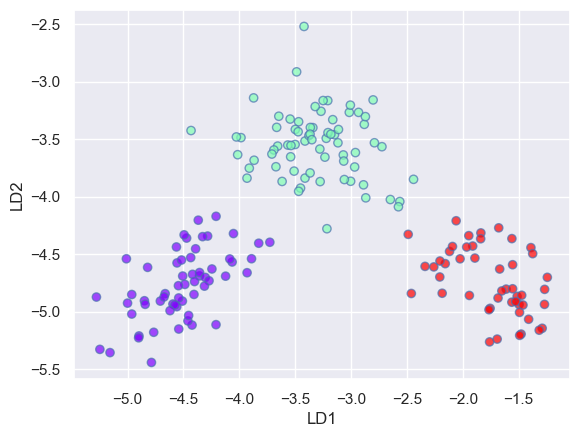

In [25]:
plt.xlabel('LD1')
plt.ylabel('LD2')

plt.scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=y,
    cmap='rainbow',
    alpha=0.7,
    edgecolors='b'
)

## LDA using scikit-learn.discriminant_analysis

Rather than implementing the Linear Discriminant Analysis algorithm from scratch every time, we can use the predefined ```LinearDiscriminantAnalysis``` class made available to us by the ```scikit-learn``` library.

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

We can access the following property to obtain the variance explained by each component.

In [27]:
lda = LinearDiscriminantAnalysis()

In [28]:
X_lda = lda.fit_transform(X, y)

In [29]:
lda.explained_variance_ratio_

array([0.6875, 0.3125])

Just like before, we plot the two LDA components.

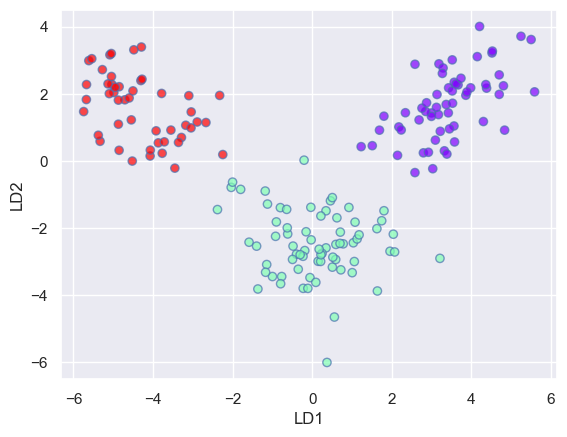

In [30]:
plt.xlabel('LD1')
plt.ylabel('LD2')

plt.scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=y,
    cmap='rainbow',
    alpha=0.7,
    edgecolors='b'
)

## Comparison with PCA

Next, let’s take a look at how LDA compares to Principal Component Analysis or PCA. We start off by creating and fitting an instance of the ```PCA``` class.

In [31]:
from sklearn.decomposition import PCA

In [32]:
pca = PCA(n_components=2)

In [33]:
X_pca = pca.fit_transform(X, y)

We can access the ```explained_variance_ratio_``` property to view the percentage of the variance explained by each component.

In [34]:
pca.explained_variance_ratio_

array([0.9981, 0.0017])

As we can see, PCA selected the components which would result in the highest spread (retain the most information) and not necessarily the ones which maximize the separation between classes.

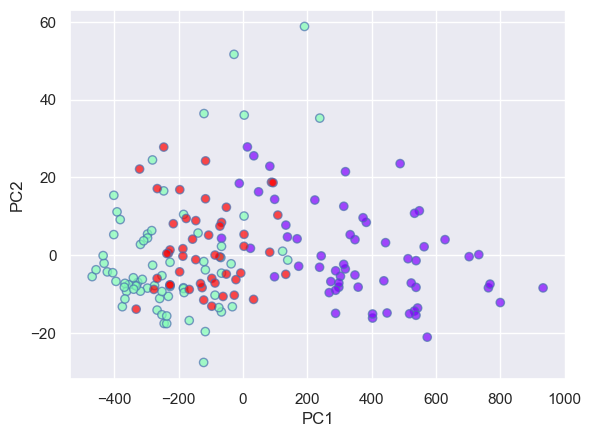

In [35]:
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='rainbow',
    alpha=0.7,
    edgecolors='b'
)

#### Comparing it to the results from LDA

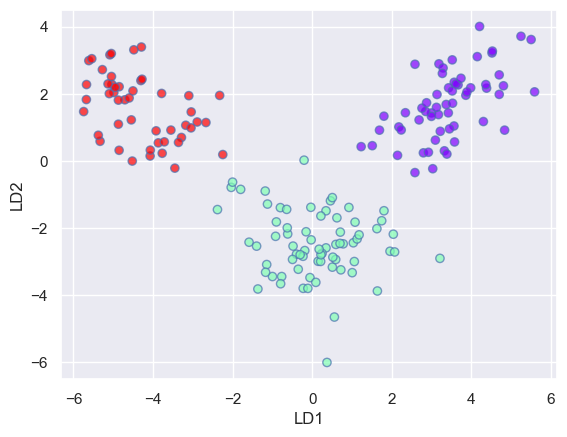

In [36]:
plt.xlabel('LD1')
plt.ylabel('LD2')

plt.scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=y,
    cmap='rainbow',
    alpha=0.7,
    edgecolors='b'
)

## After LDA, using DecisionTree Classifier to detect cluster

Next, let’s see whether we can create a model to classify the using the LDA components as features. First, we split the data into training and testing sets.

#### First split the LDA components & Known classes into Train & Test data sets

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, random_state=1)

Then, we build and train a Decision Tree. After predicting the category of each sample in the test set, we create a confusion matrix to evaluate the model’s performance.

#### Build the DecisionTreeClassifier model & fit the model

In [38]:
dt = DecisionTreeClassifier()

In [39]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

#### Make out-of-sample prediction using X_test

In [40]:
y_pred = dt.predict(X_test)

#### Exam the classification results by comparing the y_test and y_pred

In [41]:
cm=confusion_matrix(y_test, y_pred)

In [42]:
# Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
cm_df = pd.DataFrame(cm,
                     index = ['Class_0','Class_1','Class_3'], 
                     columns = ['Class_0','Class_1','Class_3'])

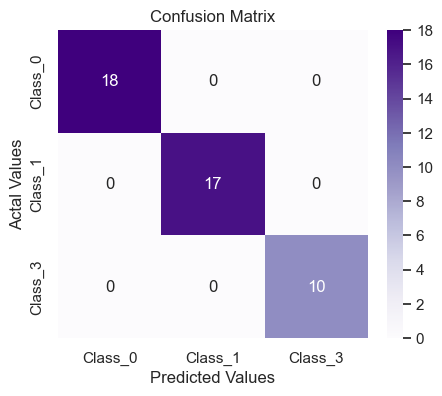

In [43]:
#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt = 'd', cmap = 'Purples')
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

In [44]:
from sklearn.metrics import classification_report
target_names = ['Class_0','Class_1','Class_3']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00        18
     Class_1       1.00      1.00      1.00        17
     Class_3       1.00      1.00      1.00        10

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



As we can see, the Decision Tree classifier correctly classified everything in the test set.

### That is it! Good Job!

#### reference: 
* https://towardsdatascience.com/linear-discriminant-analysis-in-python-76b8b17817c2
* https://sebastianraschka.com/Articles/2014_python_lda.html#lda-in-5-steps